# Image Preprocessing Experiments for all CNNS

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 566, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 566 (delta 40), reused 64 (delta 27), pack-reused 483 (from 1)
Receiving objects: 100% (566/566), 16.99 MiB | 8.03 MiB/s, done.
Resolving deltas: 100% (289/289), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, PREDICTION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels = val_df['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE = len(train_df)
# No. of training samples in training dataframe for class weight
TOTAL_TRAINING_SAMPLES = len(train_df)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df, CLASSES, TOTAL_TRAINING_SAMPLES)

## CLAHE + Median Blur Image Preprocessing Experiment

In [ ]:
# CLAHE + Median Blur + Baseline (resizing + model-specific normalization) preprocessing
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

#### tf.data Dataset Preparation for CLAHE + Median Blur Preprocessing

In [ ]:
# Generate training and validation datasets for the given image preprocessor
train_dataset_ipp1 = dataset_preparation(train_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset_ipp1 = dataset_preparation(val_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_ipp1 = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_ipp1, train_time_vgg16_ipp1, peak_memory_vgg16_ipp1 = train_selected_model(vgg16_model_ipp1,
                                                                                 train_dataset_ipp1,
                                                                                 val_dataset_ipp1,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 498ms/step - accuracy: 0.5196 - auc: 0.4990 - loss: 1.0381 - precision: 0.4013 - recall: 0.4248 - val_accuracy: 0.5843 - val_auc: 0.5824 - val_loss: 0.7436 - val_precision: 0.4703 - val_recall: 0.4826
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 475ms/step - accuracy: 0.5925 - auc: 0.5799 - loss: 0.8245 - precision: 0.4864 - recall: 0.4558 - val_accuracy: 0.6218 - val_auc: 0.5950 - val_loss: 0.6736 - val_precision: 0.5267 - val_recall: 0.3435
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 475ms/step - accuracy: 0.5956 - auc: 0.5977 - loss: 0.7789 - precision: 0.4904 - recall: 0.4502 - val_accuracy: 0.6235 - val_auc: 0.6164 - val_loss: 0.6493 - val_precision: 0.5354 - val_recall: 0.2957
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 483ms/step - accuracy: 0.6035 - auc: 0.5993 - loss: 0.7762 - precision: 0.5012 - recall: 0.4668 - val_accuracy: 0.6286 - val_auc: 0.6163 - val_loss: 0.6330 - val_precision: 0.554

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_ipp1, predictions_vgg16_ipp1, metrics_dict_vgg16_ipp1, infer_time_vgg16_ipp1 = generate_predictions_and_evaluations(vgg16_ipp1,
                                                                                                                                 val_dataset_ipp1,
                                                                                                                                 val_true_labels,
                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 271ms/step - accuracy: 0.6644 - auc: 0.6554 - loss: 0.5940 - precision: 0.6701 - recall: 0.2826


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_ipp1_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_vgg16_ipp1,
    train_time=train_time_vgg16_ipp1,
    infer_time=infer_time_vgg16_ipp1,
    peak_memory=peak_memory_vgg16_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_ipp1_results_df, 'image_preprocessing')

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


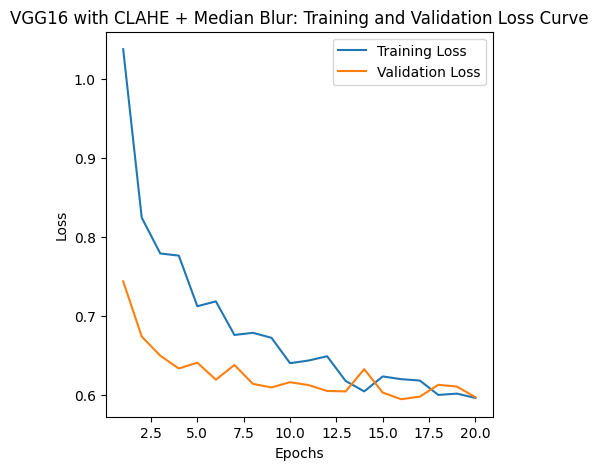

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_ipp1.history, 'VGG16', 'CLAHE + Median Blur')

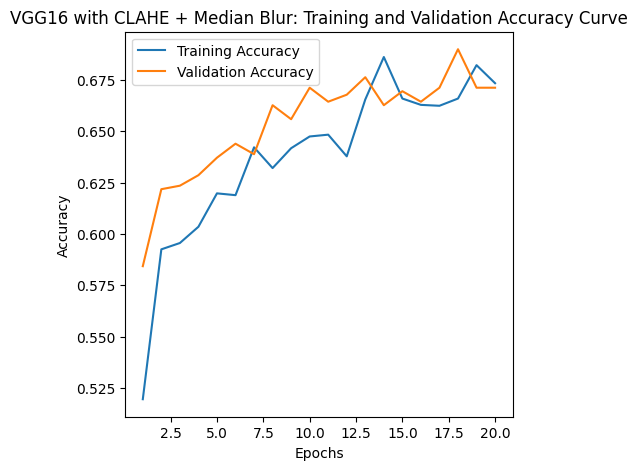

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_ipp1.history, 'VGG16', 'CLAHE + Median Blur')

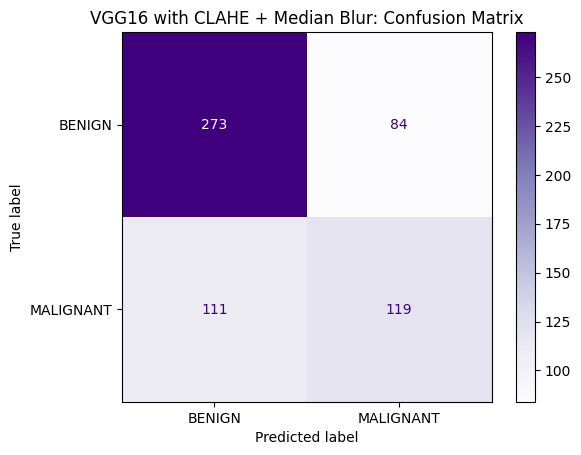

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_vgg16_ipp1, 'VGG16', 'CLAHE + Median Blur')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_ipp1 = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_ipp1, train_time_resnet50_ipp1, peak_memory_resnet50_ipp1 = train_selected_model(resnet50_model_ipp1,
                                                                                          train_dataset_ipp1,
                                                                                          val_dataset_ipp1,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 523ms/step - accuracy: 0.6154 - auc: 0.5960 - loss: 0.6927 - precision: 0.5207 - recall: 0.4027 - val_accuracy: 0.6593 - val_auc: 0.6677 - val_loss: 0.6042 - val_precision: 0.6190 - val_recall: 0.3391
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 475ms/step - accuracy: 0.6488 - auc: 0.6448 - loss: 0.6397 - precision: 0.5775 - recall: 0.4325 - val_accuracy: 0.6882 - val_auc: 0.7174 - val_loss: 0.6305 - val_precision: 0.6026 - val_recall: 0.6000
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 477ms/step - accuracy: 0.6695 - auc: 0.6811 - loss: 0.6064 - precision: 0.6044 - recall: 0.4867 - val_accuracy: 0.6814 - val_auc: 0.6845 - val_loss: 0.5775 - val_precision: 0.7416 - val_recall: 0.2870
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 477ms/step - accuracy: 0.6668 - auc: 0.6781 - loss: 0.6085 - precision: 0.6096 - recall: 0.4491 - val_accuracy: 0.6951 - val_auc: 0.7358 - val_loss: 0.6069 - val_precision: 0.618

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_ipp1, predictions_resnet50_ipp1, metrics_dict_resnet50_ipp1, infer_time_resnet50_ipp1 = generate_predictions_and_evaluations(resnet50_ipp1,
                                                                                                                                             val_dataset_ipp1,
                                                                                                                                             val_true_labels,
                                                                                                                                             PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 349ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.7087 - auc: 0.7021 - loss: 0.5381 - precision: 0.7611 - recall: 0.3739


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_ipp1_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_resnet50_ipp1,
    train_time=train_time_resnet50_ipp1,
    infer_time=infer_time_resnet50_ipp1,
    peak_memory=peak_memory_resnet50_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_ipp1_results_df, 'image_preprocessing')

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


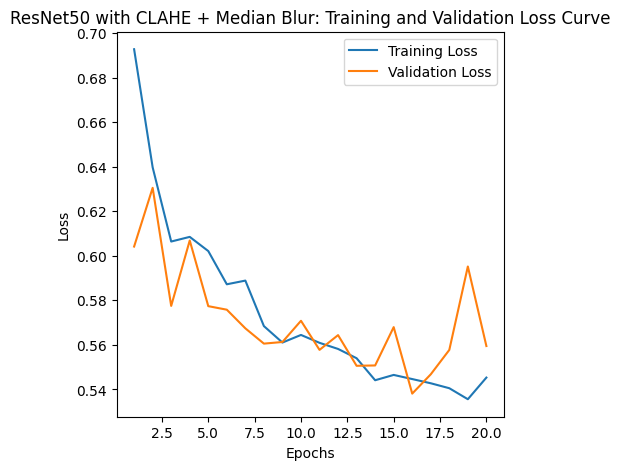

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_ipp1.history, 'ResNet50', 'CLAHE + Median Blur')

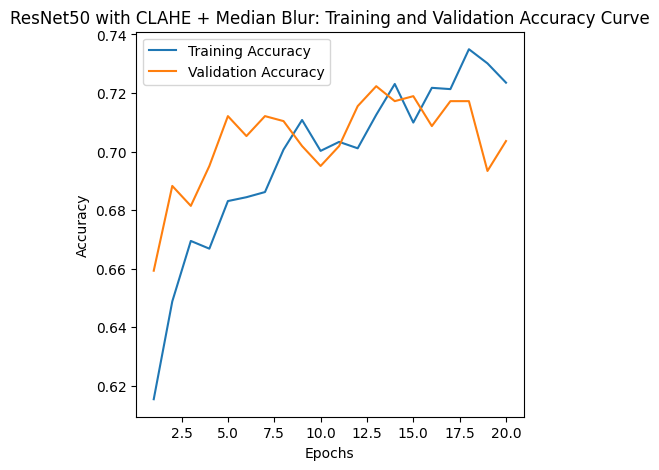

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_ipp1.history, 'ResNet50', 'CLAHE + Median Blur')

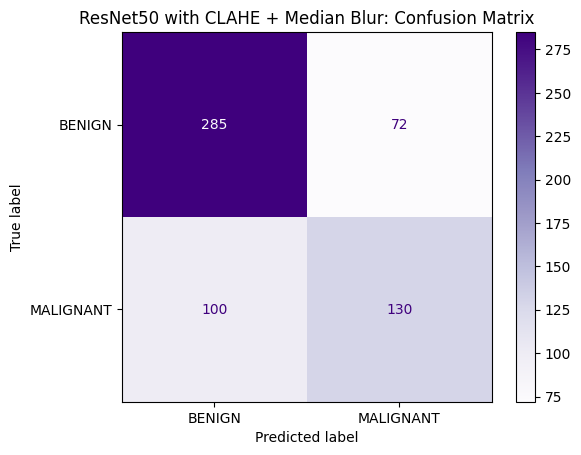

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_resnet50_ipp1, 'ResNet50', 'CLAHE + Median Blur')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_ipp1 = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_ipp1, train_time_densenet121_ipp1, peak_memory_densenet121_ipp1 = train_selected_model(densenet121_model_ipp1,
                                                                                             train_dataset_ipp1,
                                                                                             val_dataset_ipp1,
                                                                                             EXPERIMENTAL_EPOCHS,
                                                                                             early_stopping,
                                                                                             class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 563ms/step - accuracy: 0.5503 - auc: 0.5369 - loss: 1.2791 - precision: 0.4368 - recall: 0.4546 - val_accuracy: 0.6184 - val_auc: 0.5566 - val_loss: 0.7038 - val_precision: 0.5375 - val_recall: 0.1870
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 475ms/step - accuracy: 0.5749 - auc: 0.5601 - loss: 1.0494 - precision: 0.4620 - recall: 0.4237 - val_accuracy: 0.6320 - val_auc: 0.5921 - val_loss: 0.6850 - val_precision: 0.5583 - val_recall: 0.2913
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 473ms/step - accuracy: 0.5864 - auc: 0.5658 - loss: 0.9300 - precision: 0.4754 - recall: 0.3960 - val_accuracy: 0.6405 - val_auc: 0.6012 - val_loss: 0.6506 - val_precision: 0.5856 - val_recall: 0.2826
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 480ms/step - accuracy: 0.6180 - auc: 0.6065 - loss: 0.8106 - precision: 0.5231 - recall: 0.4392 - val_accuracy: 0.6303 - val_auc: 0.6052 - val_loss: 0.6293 - val_precision: 0.638

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_ipp1, predictions_densenet121_ipp1, metrics_dict_densenet121_ipp1, infer_time_densenet121_ipp1 = generate_predictions_and_evaluations(
                                                                                                                                                 densenet121_ipp1,
                                                                                                                                                 val_dataset_ipp1,
                                                                                                                                                 val_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 395ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - accuracy: 0.6184 - auc: 0.5566 - loss: 0.7038 - precision: 0.5375 - recall: 0.1870


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_ipp1_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_densenet121_ipp1,
    train_time=train_time_densenet121_ipp1,
    infer_time=infer_time_densenet121_ipp1,
    peak_memory=peak_memory_densenet121_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_ipp1_results_df, 'image_preprocessing')

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


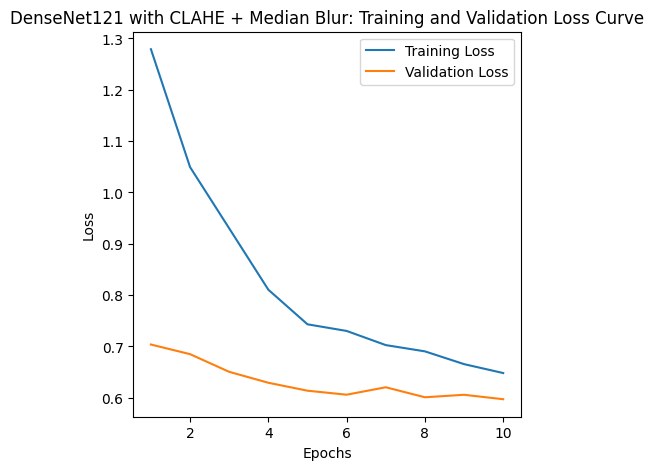

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_ipp1.history, 'DenseNet121', 'CLAHE + Median Blur')

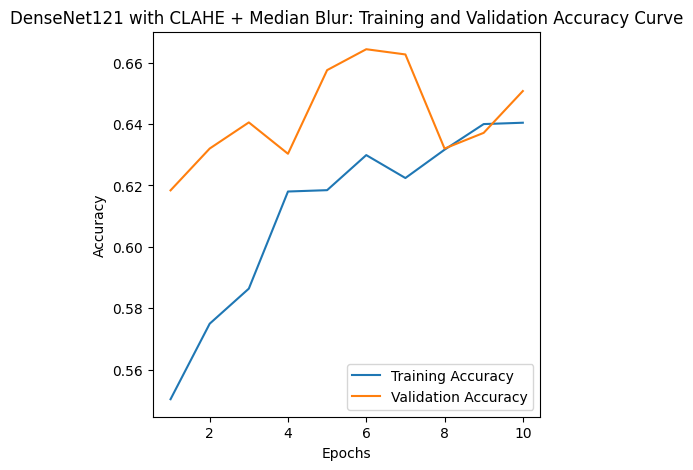

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_ipp1.history, 'DenseNet121', 'CLAHE + Median Blur')

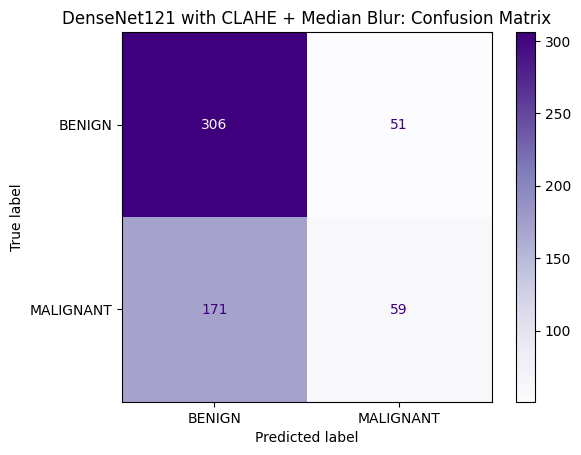

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_densenet121_ipp1, 'DenseNet121', 'CLAHE + Median Blur')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_ipp1 = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_ipp1, train_time_mobilenetv2_ipp1, peak_memory_mobilenetv2_ipp1 = train_selected_model(mobilenetv2_model_ipp1,
                                                                                                   train_dataset_ipp1,
                                                                                                   val_dataset_ipp1,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 474ms/step - accuracy: 0.5574 - auc: 0.5324 - loss: 0.7442 - precision: 0.4221 - recall: 0.3086 - val_accuracy: 0.6354 - val_auc: 0.5887 - val_loss: 0.6519 - val_precision: 0.6111 - val_recall: 0.1913
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 444ms/step - accuracy: 0.6031 - auc: 0.5884 - loss: 0.7014 - precision: 0.5008 - recall: 0.3385 - val_accuracy: 0.6252 - val_auc: 0.6235 - val_loss: 0.6902 - val_precision: 0.5278 - val_recall: 0.4130
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 416ms/step - accuracy: 0.6224 - auc: 0.6231 - loss: 0.6659 - precision: 0.5366 - recall: 0.3650 - val_accuracy: 0.6371 - val_auc: 0.6175 - val_loss: 0.6581 - val_precision: 0.5630 - val_recall: 0.3304
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 414ms/step - accuracy: 0.6347 - auc: 0.6285 - loss: 0.6609 - precision: 0.5575 - recall: 0.3916 - val_accuracy: 0.6440 - val_auc: 0.6344 - val_loss: 0.6585 - val_precision: 0.5802 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_ipp1, predictions_mobilenetv2_ipp1, metrics_dict_mobilenetv2_ipp1, infer_time_mobilenetv2_ipp1 = generate_predictions_and_evaluations(
                                                                                                                                                 mobilenetv2_ipp1,
                                                                                                                                                 val_dataset_ipp1,
                                                                                                                                                 val_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.6354 - auc: 0.5887 - loss: 0.6519 - precision: 0.6111 - recall: 0.1913


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_ipp1_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_mobilenetv2_ipp1,
    train_time=train_time_mobilenetv2_ipp1,
    infer_time=infer_time_mobilenetv2_ipp1,
    peak_memory=peak_memory_mobilenetv2_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_ipp1_results_df, 'image_preprocessing')

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


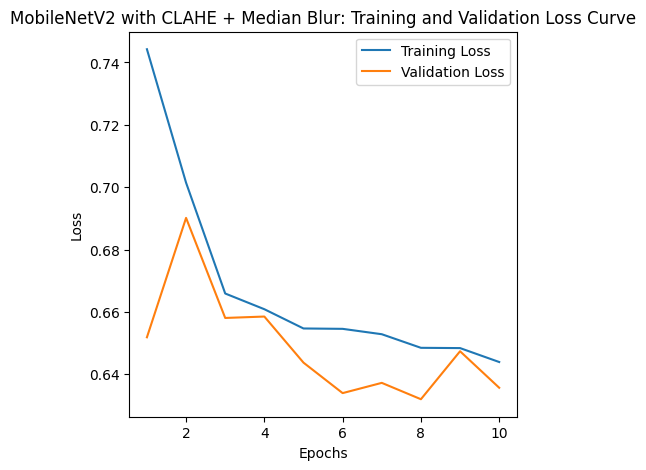

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_ipp1.history, 'MobileNetV2', 'CLAHE + Median Blur')

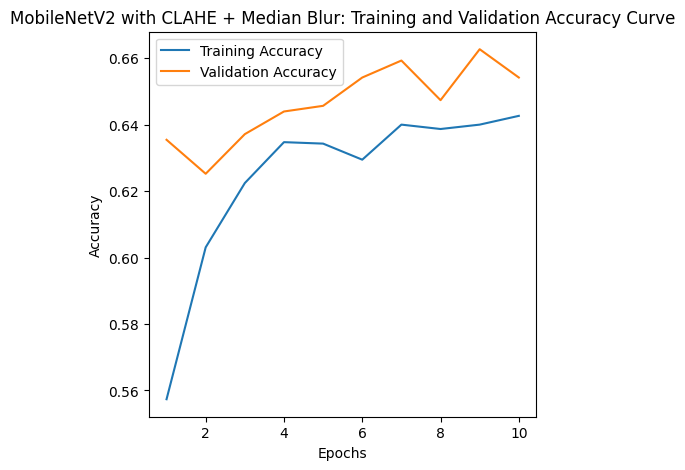

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_ipp1.history, 'MobileNetV2', 'CLAHE + Median Blur')

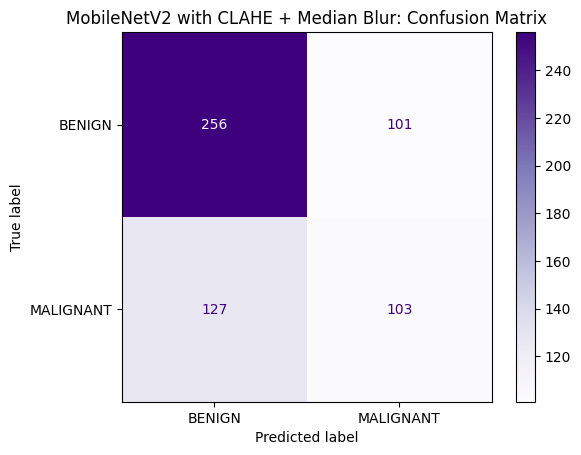

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_mobilenetv2_ipp1, 'MobileNetV2', 'CLAHE + Median Blur')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_ipp1 = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_ipp1, train_time_efficientnetb0_ipp1, peak_memory_efficientnetb0_ipp1 = train_selected_model(efficientnetb0_model_ipp1,
                                                                                                            train_dataset_ipp1,
                                                                                                            val_dataset_ipp1,
                                                                                                            EXPERIMENTAL_EPOCHS,
                                                                                                            early_stopping,
                                                                                                            class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 496ms/step - accuracy: 0.6343 - auc: 0.6225 - loss: 0.6532 - precision: 0.5887 - recall: 0.2644 - val_accuracy: 0.6440 - val_auc: 0.6775 - val_loss: 0.6369 - val_precision: 0.5512 - val_recall: 0.4913
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 453ms/step - accuracy: 0.6607 - auc: 0.6600 - loss: 0.6227 - precision: 0.6104 - recall: 0.4038 - val_accuracy: 0.6457 - val_auc: 0.6907 - val_loss: 0.6343 - val_precision: 0.5474 - val_recall: 0.5522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 448ms/step - accuracy: 0.6664 - auc: 0.6736 - loss: 0.6120 - precision: 0.6274 - recall: 0.3949 - val_accuracy: 0.6508 - val_auc: 0.6964 - val_loss: 0.6427 - val_precision: 0.5498 - val_recall: 0.6000
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 433ms/step - accuracy: 0.6637 - auc: 0.6877 - loss: 0.6036 - precision: 0.6134 - recall: 0.4159 - val_accuracy: 0.6712 - val_auc: 0.7002 - val_loss: 0.6187 - val_precision: 0.589

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_ipp1, predictions_efficientnetb0_ipp1, metrics_dict_efficientnetb0_ipp1, infer_time_efficientnetb0_ipp1 = generate_predictions_and_evaluations(
                                                                                                                                            efficientnetb0_ipp1,
                                                                                                                                            val_dataset_ipp1,
                                                                                                                                            val_true_labels,
                                                                                                                                            PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.6440 - auc: 0.6775 - loss: 0.6369 - precision: 0.5512 - recall: 0.4913


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_ipp1_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_efficientnetb0_ipp1,
    train_time=train_time_efficientnetb0_ipp1,
    infer_time=infer_time_efficientnetb0_ipp1,
    peak_memory=peak_memory_efficientnetb0_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_ipp1_results_df, 'image_preprocessing')

Stored results for 0    CLAHE + Median Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


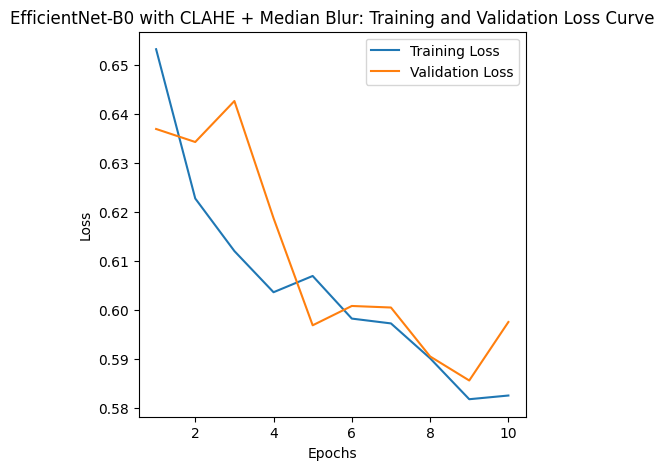

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_ipp1.history, 'EfficientNet-B0', 'CLAHE + Median Blur')

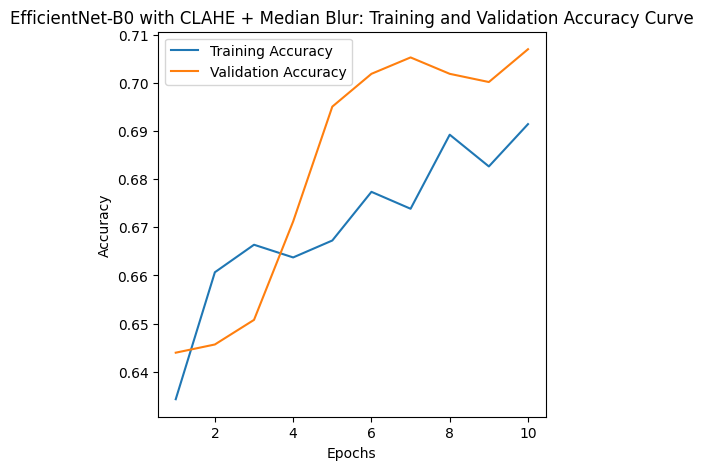

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_ipp1.history, 'EfficientNet-B0', 'CLAHE + Median Blur')

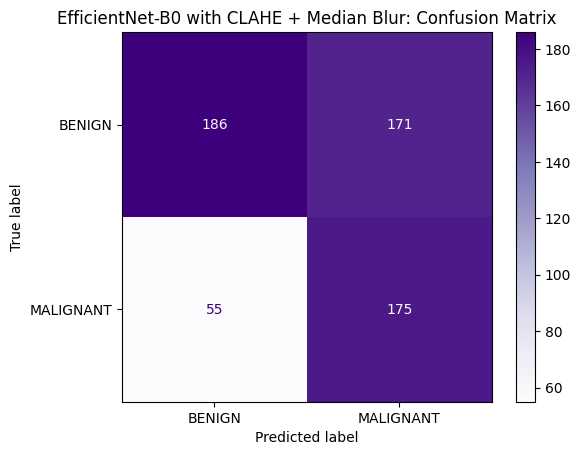

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_efficientnetb0_ipp1, 'EfficientNet-B0', 'CLAHE + Median Blur')

## Histogram Equalization + Gaussian Blur Image Preprocessing Experiment

In [ ]:
# Histogram Equalization + Gaussian Blur + Baseline (resizing + model-specific normalization) preprocessing
histo_equalized_gauss_blur_preprocessor = IMAGE_PREPROCESSORS['histogram_equalization_gaussian_blur']

#### tf.data Dataset Preparation for Histogram Equalization + Gaussian Blur Preprocessing

In [ ]:
# Generate training and validation datasets for the given image preprocessor
train_dataset_ipp2 = dataset_preparation(train_df, histo_equalized_gauss_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset_ipp2 = dataset_preparation(val_df, histo_equalized_gauss_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_ipp2 = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_ipp2, train_time_vgg16_ipp2, peak_memory_vgg16_ipp2 = train_selected_model(vgg16_model_ipp2,
                                                                                 train_dataset_ipp2,
                                                                                 val_dataset_ipp2,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 520ms/step - accuracy: 0.5297 - auc: 0.5112 - loss: 1.0692 - precision: 0.4102 - recall: 0.4192 - val_accuracy: 0.5860 - val_auc: 0.5915 - val_loss: 0.7992 - val_precision: 0.4777 - val_recall: 0.6043
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 527ms/step - accuracy: 0.5758 - auc: 0.5693 - loss: 0.8926 - precision: 0.4663 - recall: 0.4668 - val_accuracy: 0.5963 - val_auc: 0.5885 - val_loss: 0.6906 - val_precision: 0.4780 - val_recall: 0.3304
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 542ms/step - accuracy: 0.6026 - auc: 0.5907 - loss: 0.8359 - precision: 0.5000 - recall: 0.4624 - val_accuracy: 0.6133 - val_auc: 0.6016 - val_loss: 0.6751 - val_precision: 0.5097 - val_recall: 0.3435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 545ms/step - accuracy: 0.5947 - auc: 0.5868 - loss: 0.8303 - precision: 0.4899 - recall: 0.4812 - val_accuracy: 0.6184 - val_auc: 0.5867 - val_loss: 0.6528 - val_precision: 0.526

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_ipp2, predictions_vgg16_ipp2, metrics_dict_vgg16_ipp2, infer_time_vgg16_ipp2 = generate_predictions_and_evaluations(vgg16_ipp2,
                                                                                                                                 val_dataset_ipp2,
                                                                                                                                 val_true_labels,
                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 248ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.6593 - auc: 0.6368 - loss: 0.5953 - precision: 0.6562 - recall: 0.2739


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_ipp2_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_vgg16_ipp2,
    train_time=train_time_vgg16_ipp2,
    infer_time=infer_time_vgg16_ipp2,
    peak_memory=peak_memory_vgg16_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_ipp2_results_df, 'image_preprocessing')

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


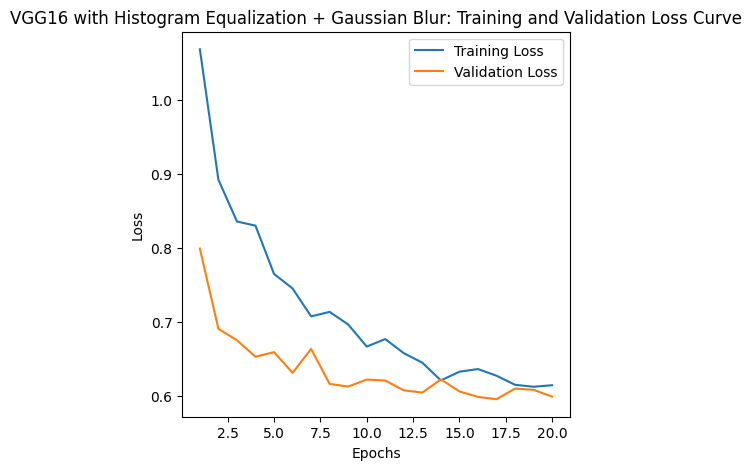

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_ipp2.history, 'VGG16', 'Histogram Equalization + Gaussian Blur')

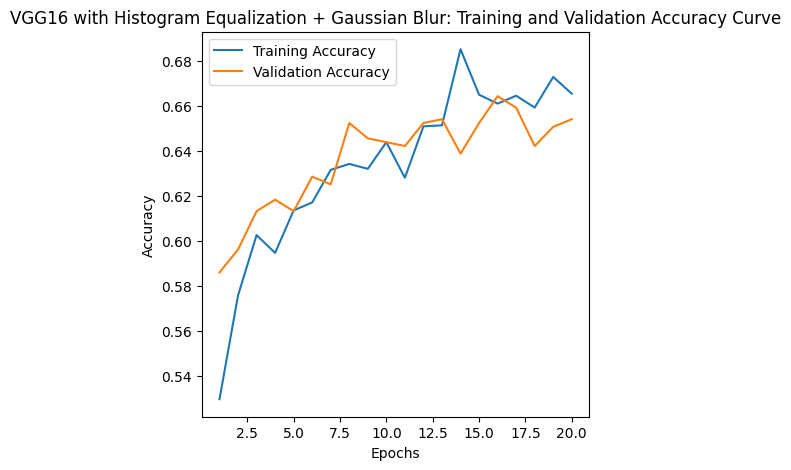

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_ipp2.history, 'VGG16', 'Histogram Equalization + Gaussian Blur')

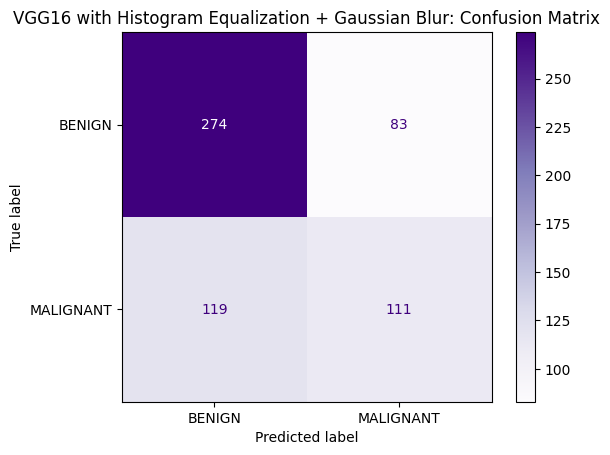

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_vgg16_ipp2, 'VGG16', 'Histogram Equalization + Gaussian Blur')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_ipp2 = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_ipp2, train_time_resnet50_ipp2, peak_memory_resnet50_ipp2 = train_selected_model(resnet50_model_ipp2,
                                                                                          train_dataset_ipp2,
                                                                                          val_dataset_ipp2,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 575ms/step - accuracy: 0.5991 - auc: 0.5841 - loss: 0.7274 - precision: 0.4944 - recall: 0.3872 - val_accuracy: 0.6695 - val_auc: 0.6743 - val_loss: 0.6225 - val_precision: 0.5989 - val_recall: 0.4739
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 537ms/step - accuracy: 0.6404 - auc: 0.6440 - loss: 0.6527 - precision: 0.5616 - recall: 0.4336 - val_accuracy: 0.6712 - val_auc: 0.7047 - val_loss: 0.6236 - val_precision: 0.5830 - val_recall: 0.5652
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 518ms/step - accuracy: 0.6699 - auc: 0.6756 - loss: 0.6207 - precision: 0.6058 - recall: 0.4845 - val_accuracy: 0.6763 - val_auc: 0.6848 - val_loss: 0.5667 - val_precision: 0.6852 - val_recall: 0.3217
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 509ms/step - accuracy: 0.6738 - auc: 0.6819 - loss: 0.6121 - precision: 0.6220 - recall: 0.4569 - val_accuracy: 0.7002 - val_auc: 0.7257 - val_loss: 0.5914 - val_precision: 0.645

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_ipp2, predictions_resnet50_ipp2, metrics_dict_resnet50_ipp2, infer_time_resnet50_ipp2 = generate_predictions_and_evaluations(resnet50_ipp2,
                                                                                                                                             val_dataset_ipp2,
                                                                                                                                             val_true_labels,
                                                                                                                                             PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 318ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.7019 - auc: 0.7003 - loss: 0.5484 - precision: 0.7350 - recall: 0.3739


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_ipp2_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_resnet50_ipp2,
    train_time=train_time_resnet50_ipp2,
    infer_time=infer_time_resnet50_ipp2,
    peak_memory=peak_memory_resnet50_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_ipp2_results_df, 'image_preprocessing')

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


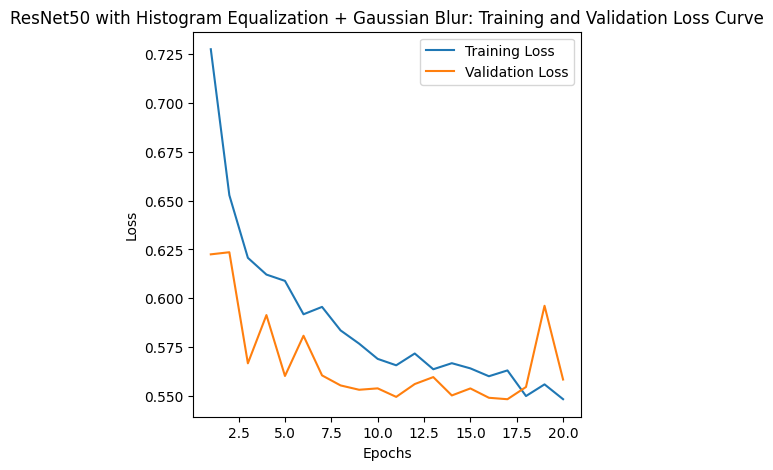

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_ipp2.history, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

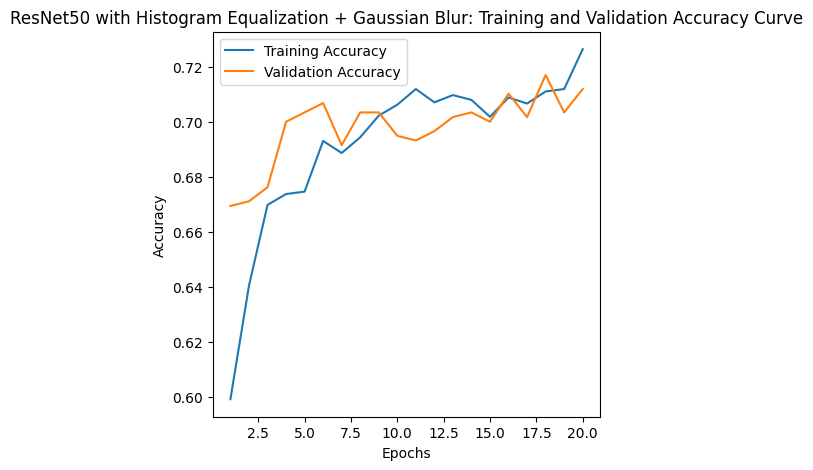

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_ipp2.history, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

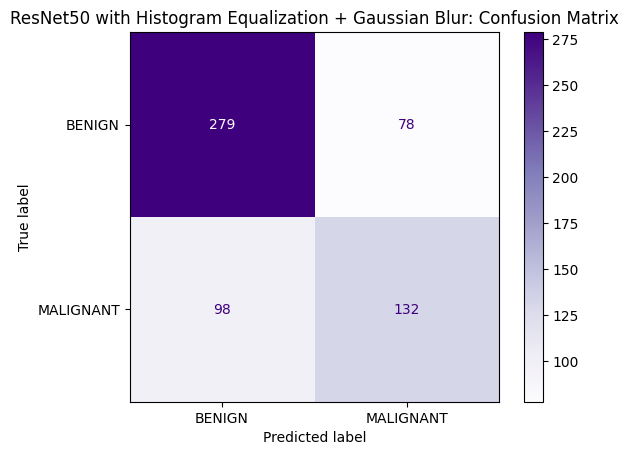

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_resnet50_ipp2, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_ipp2 = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_ipp2, train_time_densenet121_ipp2, peak_memory_densenet121_ipp2 = train_selected_model(densenet121_model_ipp2,
                                                                                                   train_dataset_ipp2,
                                                                                                   val_dataset_ipp2,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 608ms/step - accuracy: 0.5336 - auc: 0.5254 - loss: 1.3685 - precision: 0.4198 - recall: 0.4546 - val_accuracy: 0.6559 - val_auc: 0.6013 - val_loss: 0.6606 - val_precision: 0.6795 - val_recall: 0.2304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 532ms/step - accuracy: 0.5622 - auc: 0.5548 - loss: 1.0940 - precision: 0.4492 - recall: 0.4502 - val_accuracy: 0.6491 - val_auc: 0.6201 - val_loss: 0.6223 - val_precision: 0.6395 - val_recall: 0.2391
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 536ms/step - accuracy: 0.5785 - auc: 0.5569 - loss: 0.9299 - precision: 0.4667 - recall: 0.4259 - val_accuracy: 0.6780 - val_auc: 0.6670 - val_loss: 0.6159 - val_precision: 0.6273 - val_recall: 0.4391
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 533ms/step - accuracy: 0.6048 - auc: 0.5982 - loss: 0.7934 - precision: 0.5030 - recall: 0.4646 - val_accuracy: 0.6763 - val_auc: 0.6732 - val_loss: 0.6043 - val_precision: 0.685

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_ipp2, predictions_densenet121_ipp2, metrics_dict_densenet121_ipp2, infer_time_densenet121_ipp2 = generate_predictions_and_evaluations(
                                                                                                                                                 densenet121_ipp2,
                                                                                                                                                 val_dataset_ipp2,
                                                                                                                                                 val_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 487ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.6559 - auc: 0.6013 - loss: 0.6606 - precision: 0.6795 - recall: 0.2304


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_ipp2_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_densenet121_ipp2,
    train_time=train_time_densenet121_ipp2,
    infer_time=infer_time_densenet121_ipp2,
    peak_memory=peak_memory_densenet121_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_ipp2_results_df, 'image_preprocessing')

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


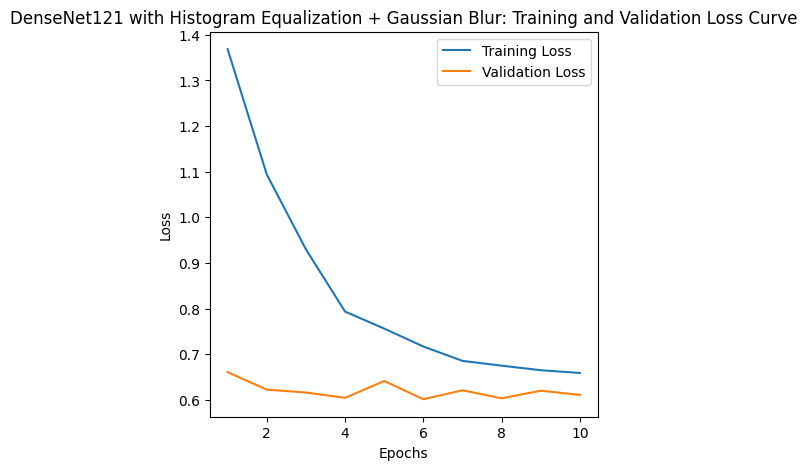

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_ipp2.history, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

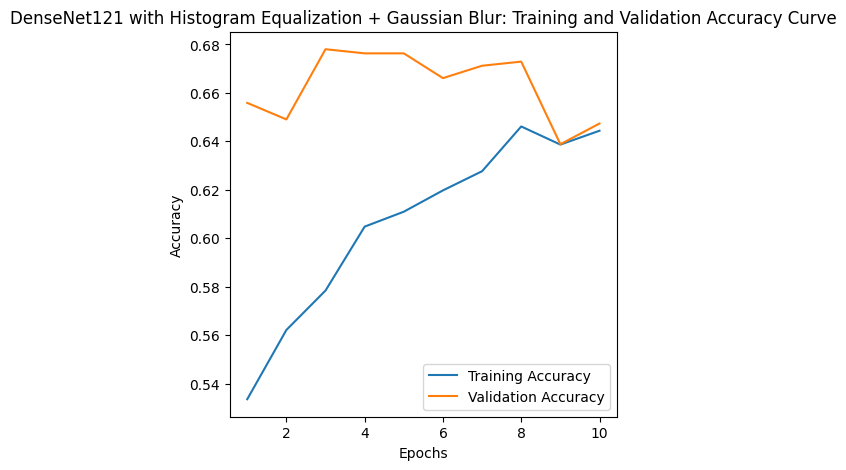

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_ipp2.history, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

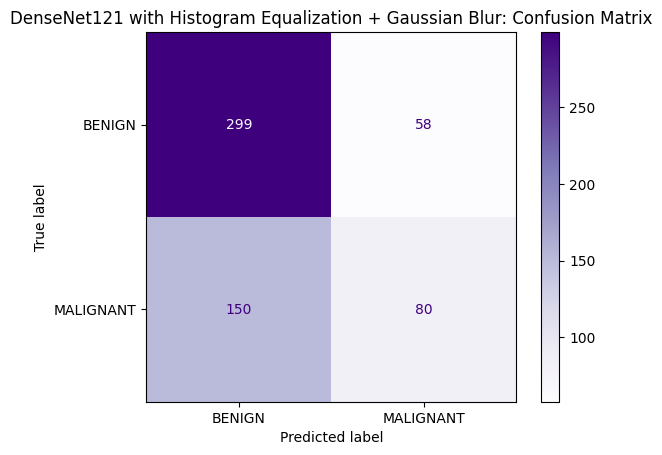

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_densenet121_ipp2, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_ipp2 = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_ipp2, train_time_mobilenetv2_ipp2, peak_memory_mobilenetv2_ipp2 = train_selected_model(mobilenetv2_model_ipp2,
                                                                                                   train_dataset_ipp2,
                                                                                                   val_dataset_ipp2,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 468ms/step - accuracy: 0.5464 - auc: 0.5124 - loss: 0.7645 - precision: 0.4083 - recall: 0.3153 - val_accuracy: 0.6201 - val_auc: 0.5881 - val_loss: 0.6443 - val_precision: 0.6842 - val_recall: 0.0565
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 446ms/step - accuracy: 0.5903 - auc: 0.5621 - loss: 0.7209 - precision: 0.4767 - recall: 0.3164 - val_accuracy: 0.6508 - val_auc: 0.6566 - val_loss: 0.6596 - val_precision: 0.6168 - val_recall: 0.2870
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 466ms/step - accuracy: 0.6167 - auc: 0.6090 - loss: 0.6794 - precision: 0.5280 - recall: 0.3341 - val_accuracy: 0.6627 - val_auc: 0.6567 - val_loss: 0.6320 - val_precision: 0.6702 - val_recall: 0.2739
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 458ms/step - accuracy: 0.6259 - auc: 0.6149 - loss: 0.6783 - precision: 0.5425 - recall: 0.3739 - val_accuracy: 0.6491 - val_auc: 0.6298 - val_loss: 0.6214 - val_precision: 0.7222 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_ipp2, predictions_mobilenetv2_ipp2, metrics_dict_mobilenetv2_ipp2, infer_time_mobilenetv2_ipp2 = generate_predictions_and_evaluations(
                                                                                                                                                 mobilenetv2_ipp2,
                                                                                                                                                 val_dataset_ipp2,
                                                                                                                                                 val_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.6201 - auc: 0.5881 - loss: 0.6443 - precision: 0.6842 - recall: 0.0565


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_ipp2_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_mobilenetv2_ipp2,
    train_time=train_time_mobilenetv2_ipp2,
    infer_time=infer_time_mobilenetv2_ipp2,
    peak_memory=peak_memory_mobilenetv2_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_ipp2_results_df, 'image_preprocessing')

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


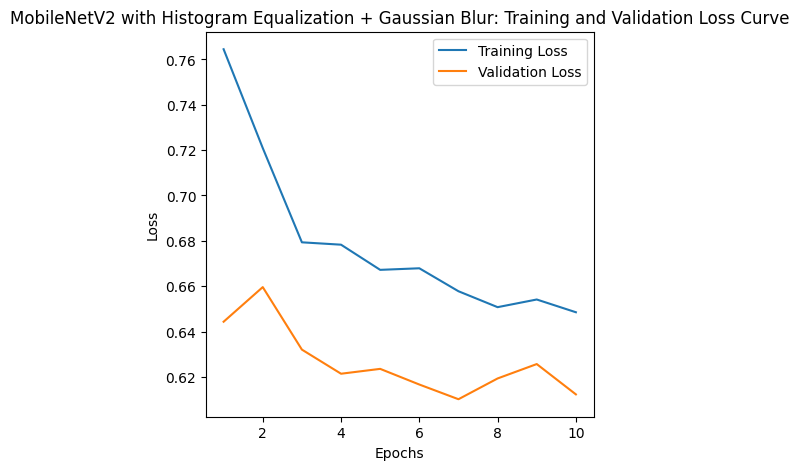

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_ipp2.history, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

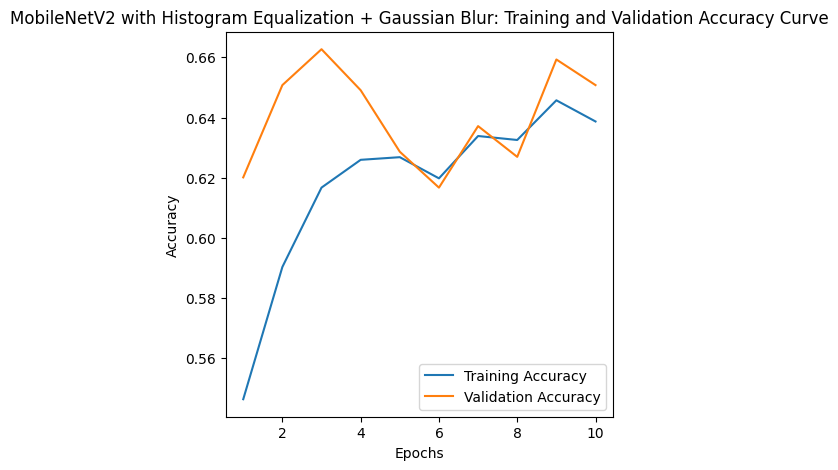

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_ipp2.history, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

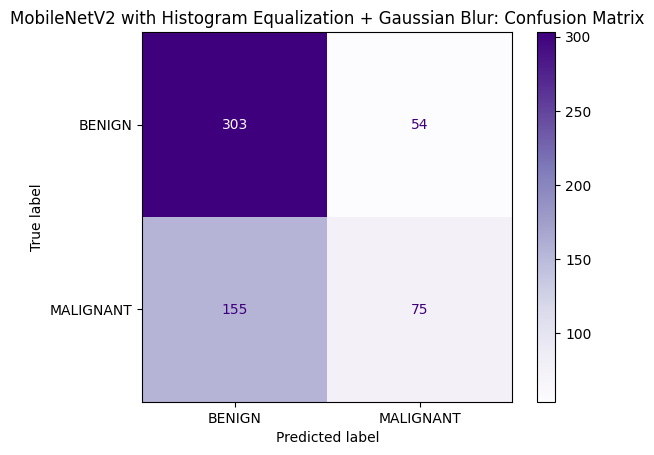

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_mobilenetv2_ipp2, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_ipp2 = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_ipp2, train_time_efficientnetb0_ipp2, peak_memory_efficientnetb0_ipp2 = train_selected_model(efficientnetb0_model_ipp2,
                                                                                                            train_dataset_ipp2,
                                                                                                            val_dataset_ipp2,
                                                                                                            EXPERIMENTAL_EPOCHS,
                                                                                                            early_stopping,
                                                                                                            class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 509ms/step - accuracy: 0.6189 - auc: 0.6003 - loss: 0.6620 - precision: 0.5491 - recall: 0.2290 - val_accuracy: 0.6508 - val_auc: 0.7051 - val_loss: 0.6271 - val_precision: 0.5740 - val_recall: 0.4217
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 453ms/step - accuracy: 0.6497 - auc: 0.6501 - loss: 0.6355 - precision: 0.5967 - recall: 0.3650 - val_accuracy: 0.6882 - val_auc: 0.7091 - val_loss: 0.6045 - val_precision: 0.6822 - val_recall: 0.3826
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 454ms/step - accuracy: 0.6598 - auc: 0.6721 - loss: 0.6179 - precision: 0.6349 - recall: 0.3385 - val_accuracy: 0.6848 - val_auc: 0.7310 - val_loss: 0.6225 - val_precision: 0.5926 - val_recall: 0.6261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 451ms/step - accuracy: 0.6743 - auc: 0.6812 - loss: 0.6097 - precision: 0.6432 - recall: 0.4049 - val_accuracy: 0.6917 - val_auc: 0.7102 - val_loss: 0.5840 - val_precision: 0.747

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_ipp2, predictions_efficientnetb0_ipp2, metrics_dict_efficientnetb0_ipp2, infer_time_efficientnetb0_ipp2 = generate_predictions_and_evaluations(
                                                                                                                                            efficientnetb0_ipp2,
                                                                                                                                            val_dataset_ipp2,
                                                                                                                                            val_true_labels,
                                                                                                                                            PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 364ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.6508 - auc: 0.7051 - loss: 0.6271 - precision: 0.5740 - recall: 0.4217


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_ipp2_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_efficientnetb0_ipp2,
    train_time=train_time_efficientnetb0_ipp2,
    infer_time=infer_time_efficientnetb0_ipp2,
    peak_memory=peak_memory_efficientnetb0_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_ipp2_results_df, 'image_preprocessing')

Stored results for 0    Histogram Equalization + Gaussian Blur
Name: image_preprocessing_pipeline, dtype: object pipeline


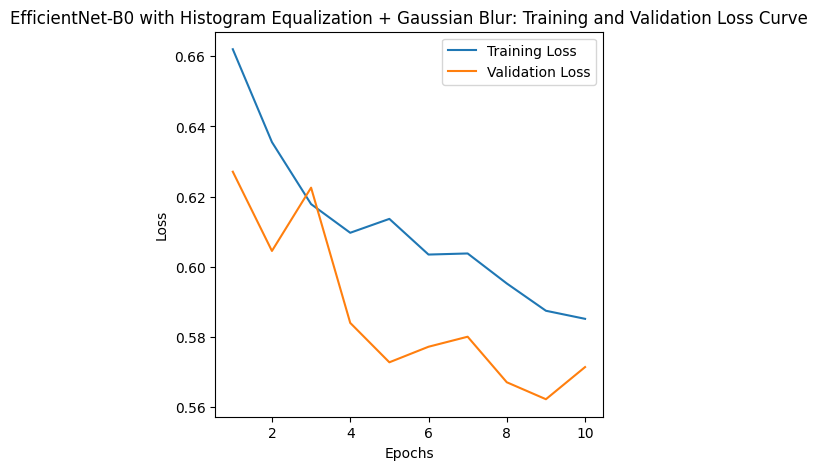

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_ipp2.history, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')

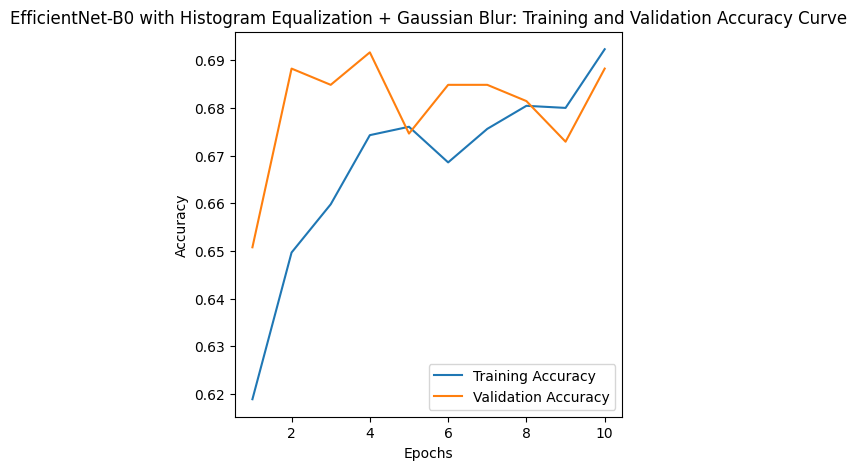

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_ipp2.history, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')

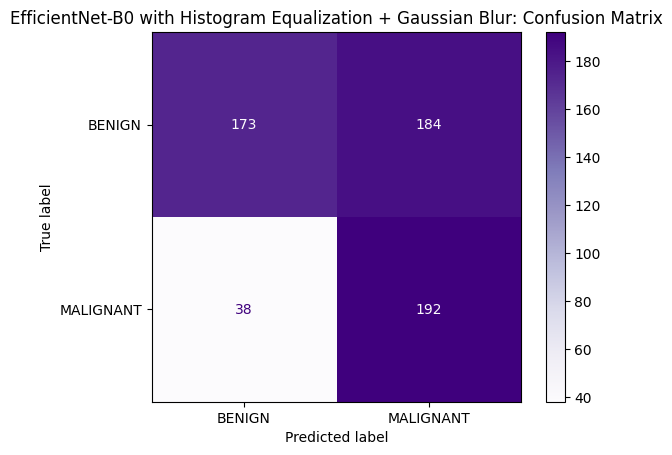

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, predictions_efficientnetb0_ipp2, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')